In [ ]:
#PROJECT BY SAKSHAM VERMA @2025

pip install yfinance

In [ ]:
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.optimize as sco
import time

GENEARTING DATASET AS 'data'

In [ ]:
# List of top 10 companies in BSE 30 (Sensex) by market cap
bse30_top10 = [
    "RELIANCE.NS", "TCS.NS", "HDFCBANK.NS", "ICICIBANK.NS", "INFY.NS",
    "HINDUNILVR.NS", "SBIN.NS", "BAJFINANCE.NS", "BHARTIARTL.NS", "KOTAKBANK.NS"
]

# Define start and end dates
start_date = "2014-01-01"
end_date = "2024-12-31"

# Fetch data from Yahoo Finance
data = yf.download(bse30_top10, start=start_date, end=end_date)['Adj Close']

# Save DataFrame to CSV
data.to_csv("bse30_closing_prices.csv")

# Display the first few rows
print(data.head())

[*********************100%***********************]  10 of 10 completed
ERROR:yfinance:
10 Failed downloads:
ERROR:yfinance:['INFY.NS', 'BAJFINANCE.NS', 'BHARTIARTL.NS', 'HINDUNILVR.NS', 'ICICIBANK.NS', 'TCS.NS', 'RELIANCE.NS', 'SBIN.NS', 'HDFCBANK.NS', 'KOTAKBANK.NS']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


Empty DataFrame
Columns: [BAJFINANCE.NS, BHARTIARTL.NS, HDFCBANK.NS, HINDUNILVR.NS, ICICIBANK.NS, INFY.NS, KOTAKBANK.NS, RELIANCE.NS, SBIN.NS, TCS.NS]
Index: []


In [ ]:
data = pd.read_csv("bse10_close.csv")
data.head()

,Date,BAJFINANCE.NS,BHARTIARTL.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,KOTAKBANK.NS,RELIANCE.NS,SBIN.NS,TCS.NS
0,2004-01-01,6.656944,46.384277,31.289846,135.359589,40.951580,58.305752,19.053537,30.679121,40.306084,27.858086
1,2004-01-02,6.706100,45.799522,30.965536,137.077408,41.465591,58.620716,18.722597,31.461344,40.409580,27.858086
2,2004-01-05,6.849731,44.797066,31.166094,136.409378,42.365105,60.895519,18.121540,31.184479,42.897263,27.858086
3,2004-01-06,6.625452,47.219666,30.850330,135.932190,42.256893,58.809013,17.922003,30.773205,42.911541,27.858086
4,2004-01-07,6.327435,46.614017,30.799131,133.578140,41.127434,58.893848,18.050974,31.189856,42.586746,27.858086


DEFINING FUNCTIONS TO GENERATE PORTOFOLIOS

In [ ]:
#EQUAL WEIGHTAGE PORTOFOLIO
def equal_wgt_port(data):
  x_equal  = np.array([0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1])
  return(x_equal)

#VALUE WEIGHATGE PORTOFOLIO TAKINH VALUE AS MEAN OF TRAIN DATA
def value_wgt_port(data):
  va_mean = data.mean()
  x_value = np.array(va_mean/va_mean.sum())
  return(x_value)

#MINIMUM SHARPE RATIO PORTOFOLIO
def sharpe_wgt_port(data, risk_free_rate=0.0):
    # Calculate daily returns
    returns = data.pct_change().dropna()

    # Compute mean returns and covariance matrix
    mean_returns = returns.mean()
    cov_matrix = returns.cov()

    num_assets = len(mean_returns)
    initial_guess = np.ones(num_assets) / num_assets  # Equal weights to start
    bounds = tuple((0, 1) for _ in range(num_assets))  # No short selling
    constraints = ({'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1})  # Weights sum to 1

    def sharpe_ratio(weights):
        portfolio_return = np.dot(weights, mean_returns)
        portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        return - (portfolio_return - risk_free_rate) / portfolio_volatility  # Negative Sharpe for minimization

    result = sco.minimize(sharpe_ratio, initial_guess, bounds=bounds, constraints=constraints)
    return result.x

#MINIMUM SORTINO RATIO PORTOFOLIO
def sortino_wgt_port(price_data, risk_free_rate=0.0):
    # Calculate daily returns
    returns = price_data.pct_change().dropna()

    # Compute mean returns
    mean_returns = returns.mean()

    num_assets = len(mean_returns)
    initial_guess = np.ones(num_assets) / num_assets  # Equal weights to start
    bounds = tuple((0, 1) for _ in range(num_assets))  # No short selling
    constraints = ({'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1})  # Weights sum to 1

    def sortino_ratio(weights):
        portfolio_return = np.dot(weights, mean_returns)
        downside_risk = np.sqrt(np.mean(np.minimum(returns @ weights - risk_free_rate, 0) ** 2))
        return - (portfolio_return - risk_free_rate) / downside_risk  # Negative Sortino for minimization

    result = sco.minimize(sortino_ratio, initial_guess, bounds=bounds, constraints=constraints)
    return result.x

GENERATING PORTOFOLIO RETURNS RESULTS

In [ ]:
#EQUAL WEIGHTAGE PORTOFOLIO
def equal_wgt_port(data):
  x_equal  = np.array([0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1])
  return(x_equal)

#VALUE WEIGHATGE PORTOFOLIO TAKINH VALUE AS MEAN OF TRAIN DATA
def value_wgt_port(data):
  # Select only numeric columns before calculating the mean
  numeric_data = data.select_dtypes(include=np.number)
  va_mean = numeric_data.mean()
  x_value = np.array(va_mean/va_mean.sum())
  return(x_value)

#MINIMUM SHARPE RATIO PORTOFOLIO
def sharpe_wgt_port(data, risk_free_rate=0.0):
    # Calculate daily returns
    numeric_data = data.select_dtypes(include=np.number)
    returns = numeric_data.pct_change().dropna()

    # Compute mean returns and covariance matrix
    mean_returns = returns.mean()
    cov_matrix = returns.cov()

    num_assets = len(mean_returns)
    initial_guess = np.ones(num_assets) / num_assets  # Equal weights to start
    bounds = tuple((0, 1) for _ in range(num_assets))  # No short selling
    constraints = ({'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1})  # Weights sum to 1

    def sharpe_ratio(weights):
        portfolio_return = np.dot(weights, mean_returns)
        portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        return - (portfolio_return - risk_free_rate) / portfolio_volatility  # Negative Sharpe for minimization

    result = sco.minimize(sharpe_ratio, initial_guess, bounds=bounds, constraints=constraints)
    return result.x

#MINIMUM SORTINO RATIO PORTOFOLIO
def sortino_wgt_port(price_data, risk_free_rate=0.0):
    # Calculate daily returns
    numeric_data = data.select_dtypes(include=np.number)
    returns = numeric_data.pct_change().dropna()

    # Compute mean returns
    mean_returns = returns.mean()

    num_assets = len(mean_returns)
    initial_guess = np.ones(num_assets) / num_assets  # Equal weights to start
    bounds = tuple((0, 1) for _ in range(num_assets))  # No short selling
    constraints = ({'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1})  # Weights sum to 1

    def sortino_ratio(weights):
        portfolio_return = np.dot(weights, mean_returns)
        downside_risk = np.sqrt(np.mean(np.minimum(returns @ weights - risk_free_rate, 0) ** 2))
        return - (portfolio_return - risk_free_rate) / downside_risk  # Negative Sortino for minimization

    result = sco.minimize(sortino_ratio, initial_guess, bounds=bounds, constraints=constraints)
    return result.x

In [ ]:
#Making Rolling window
# Define the training and test window sizes (in days)
y = 21 # test window length
x = 6*y   # training window length


# List to store the rolling cumulative returns for each portfolio strategy
rolling_results = []

# Loop over the data with a rolling window approach.
# Here, the training window is of length x and the test window is of length y.
# We shift the window by y days each time.
n = len(data)
for start in range(0, n - x - y + 1, y):
    # Define training and test datasets
    train_data = data.iloc[start : start + x]
    test_data = data.iloc[start + x : start + x + y]

    # Compute portfolio weights for each strategy using the training data
    w1 = equal_wgt_port(train_data)
    w2 = value_wgt_port(train_data)
    w3 = sharpe_wgt_port(train_data)
    w4 = sortino_wgt_port(train_data)

    # ----- Calculate Returns on Test Data -----
    # Instead of having precomputed returns, calculate each asset's return over the test period
    # using the first and last closing prices:
    # Return for each asset = (Last price / First price) - 1
    asset_test_returns = (test_data.iloc[-1] / test_data.iloc[0]) - 1

    # Now, compute the portfolio returns as the dot product of the asset returns and the weights.
    port_ret1 = np.dot(asset_test_returns, w1)
    port_ret2 = np.dot(asset_test_returns, w2)
    port_ret3 = np.dot(asset_test_returns, w3)
    port_ret4 = np.dot(asset_test_returns, w4)

    # Store the results with the corresponding test period start and end dates.
    rolling_results.append({
        'test_start': test_data.index[0],
        'test_end': test_data.index[-1],
        'portfolio1': port_ret1,
        'portfolio2': port_ret2,
        'portfolio3': port_ret3,
        'portfolio4': port_ret4
    })

# Convert the rolling results to a DataFrame.
rolling_data = pd.DataFrame(rolling_results)
print(rolling_data)
rolling_data.to_csv("rolling_data.csv")

<ipython-input-11-536086c956ad>:18: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = numeric_data.pct_change().dropna()
<ipython-input-11-536086c956ad>:41: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = numeric_data.pct_change().dropna()


TypeError: unsupported operand type(s) for /: 'str' and 'str'

RETURNS VISULAISATION

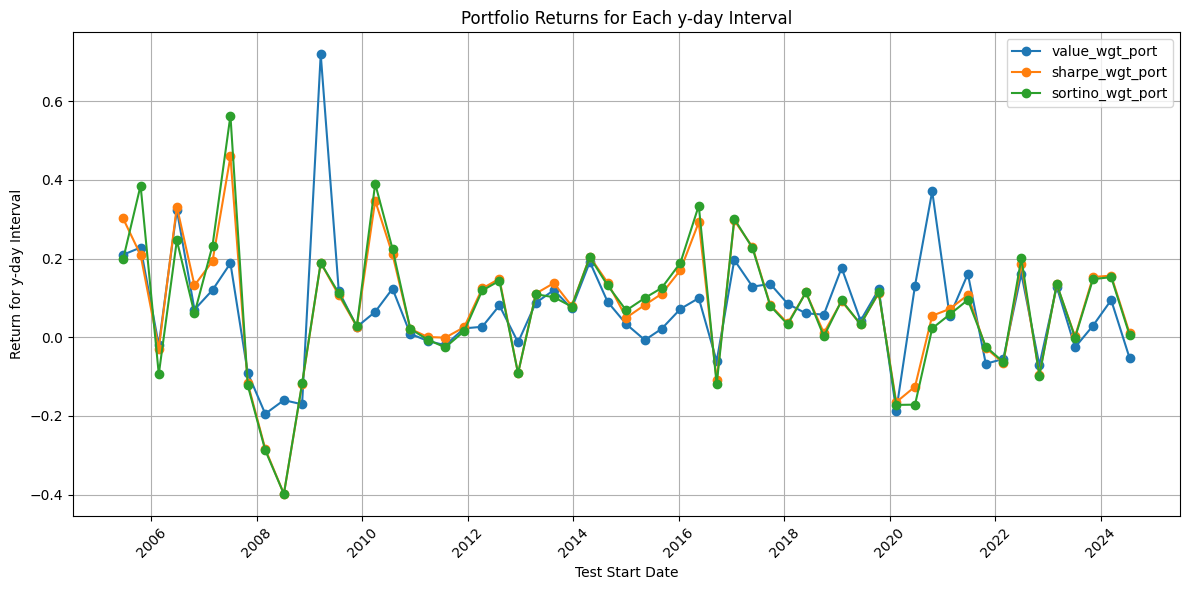

   test_start  cum_portfolio1  cum_portfolio2  cum_portfolio3  cum_portfolio4
0  2005-06-20    2.350069e+00        0.209872        0.302134        0.198203
1  2005-10-19    1.142470e+01        0.485954        0.574654        0.660446
2  2006-02-22    8.833769e+00        0.456075        0.528468        0.504881
3  2006-06-27    4.097652e+01        0.927208        1.036181        0.875604
4  2006-10-27    7.156041e+01        1.062858        1.304735        0.989150
5  2007-03-01    1.875033e+02        1.310822        1.750776        1.453178
6  2007-07-03    6.001697e+02        1.745893        3.015014        2.835647
7  2007-10-31    2.934523e+02        1.496383        2.546150        2.366378
8  2008-02-29   -4.700822e+02        1.010814        1.540009        1.400096
9  2008-07-07    3.279963e+02        0.689589        0.528801        0.444590
10 2008-11-10   -2.681597e+02        0.401834        0.346160        0.274985
11 2009-03-19   -2.680699e+03        1.410206        0.601101   

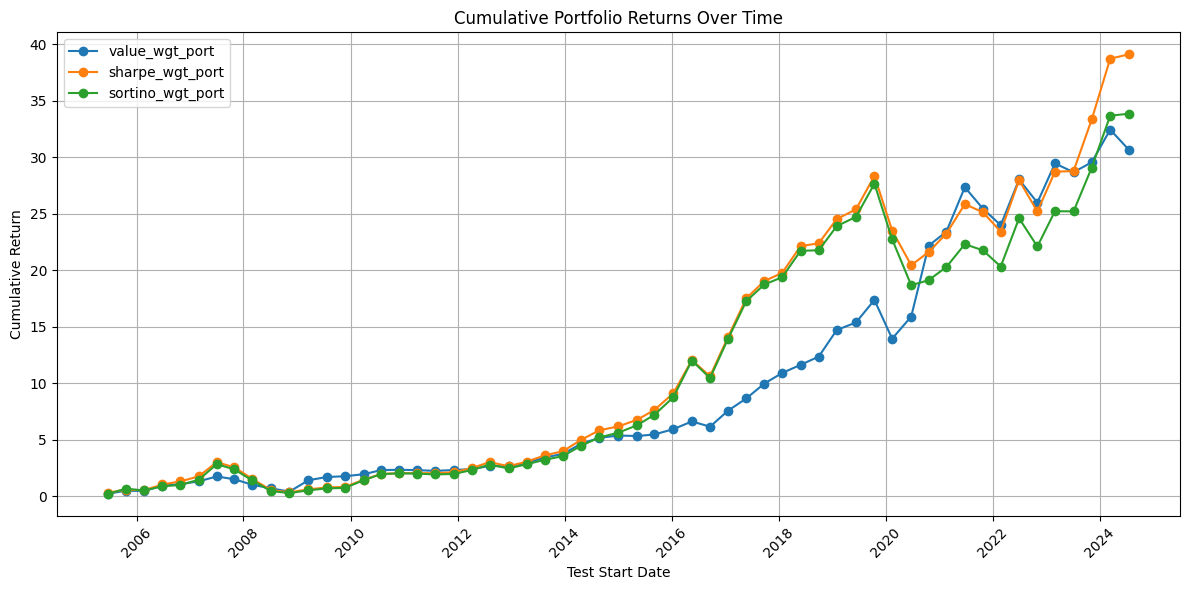

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# ----- Plot 1: Rolling y-day Interval Returns -----
plt.figure(figsize=(12, 6))

# Plot the return for each y-day test period for each portfolio.
# plt.plot(rolling_data['test_start'], rolling_data['portfolio1'], marker='o', label='Portfolio 1')
plt.plot(rolling_data['test_start'], rolling_data['portfolio2'], marker='o', label='value_wgt_port')
plt.plot(rolling_data['test_start'], rolling_data['portfolio3'], marker='o', label='sharpe_wgt_port')
plt.plot(rolling_data['test_start'], rolling_data['portfolio4'], marker='o', label='sortino_wgt_port')

plt.xlabel('Test Start Date')
plt.ylabel('Return for y-day Interval')
plt.title('Portfolio Returns for Each y-day Interval')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


# ----- Plot 2: Cumulative Returns Over All y-day Intervals -----
# Compute cumulative returns for each portfolio
rolling_data['cum_portfolio1'] = (1 + rolling_data['portfolio1']).cumprod() - 1
rolling_data['cum_portfolio2'] = (1 + rolling_data['portfolio2']).cumprod() - 1
rolling_data['cum_portfolio3'] = (1 + rolling_data['portfolio3']).cumprod() - 1
rolling_data['cum_portfolio4'] = (1 + rolling_data['portfolio4']).cumprod() - 1

# Optionally, print the DataFrame to verify the computed values
print(rolling_data[['test_start', 'cum_portfolio1', 'cum_portfolio2', 'cum_portfolio3', 'cum_portfolio4']])

# Plot cumulative returns over time
plt.figure(figsize=(12, 6))
#plt.plot(rolling_data['test_start'], rolling_data['cum_portfolio1'], marker='o', label='Portfolio 1')
plt.plot(rolling_data['test_start'], rolling_data['cum_portfolio2'], marker='o', label='value_wgt_port')
plt.plot(rolling_data['test_start'], rolling_data['cum_portfolio3'], marker='o', label='sharpe_wgt_port')
plt.plot(rolling_data['test_start'], rolling_data['cum_portfolio4'], marker='o', label='sortino_wgt_port')

plt.xlabel('Test Start Date')
plt.ylabel('Cumulative Return')
plt.title('Cumulative Portfolio Returns Over Time')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

# Display the plot
plt.show()

EVALUATION METRRICES


In [ ]:
eval_data = rolling_data[['portfolio1','portfolio2','portfolio3','portfolio4']]


def sharpe_ratio(returns, risk_free_rate=0):
    """Calculate the Sharpe Ratio (excess return / std deviation)."""
    excess_return = returns - risk_free_rate
    std = returns.std()
    return excess_return.mean() / std if std != 0 else np.nan

def sortino_ratio(returns, risk_free_rate=0):
    """Calculate the Sortino Ratio using only downside deviations."""
    excess_return = returns - risk_free_rate
    downside_returns = returns[returns < risk_free_rate]
    downside_std = downside_returns.std()
    return excess_return.mean() / downside_std if downside_std != 0 else np.nan

def volatility(returns):
    """Return the standard deviation of returns."""
    return returns.std()

def max_drawdown_and_recovery(returns):
    """
    Compute Maximum Drawdown and Recovery Rate.

    - Cumulative returns: (1 + r).cumprod()
    - Drawdown = (cumulative - running_max) / running_max
    - Maximum Drawdown is the minimum (most negative) value.
    - Recovery Rate is computed for the drawdown event.
    """
    cumulative = (1 + returns).cumprod()
    running_max = cumulative.cummax()
    drawdown = (cumulative - running_max) / running_max
    mdd = drawdown.min()  # most negative value

    # Identify the trough (date of maximum drawdown)
    trough_idx = drawdown.idxmin()

    # Identify the prior peak (the highest value before the trough)
    cumulative_before_trough = cumulative.loc[:trough_idx]
    peak_idx = cumulative_before_trough.idxmax() if not cumulative_before_trough.empty else cumulative.index[0]
    peak_value = cumulative.loc[peak_idx]
    trough_value = cumulative.loc[trough_idx]

    # Find recovery: first date after trough when cumulative returns >= prior peak
    recovery_idx = None
    for date in cumulative.loc[trough_idx:].index:
        if cumulative.loc[date] >= peak_value:
            recovery_idx = date
            break
    if recovery_idx is not None and (peak_value - trough_value) != 0:
        recovery_rate = (cumulative.loc[recovery_idx] - trough_value) / (peak_value - trough_value)
    else:
        recovery_rate = np.nan

    return mdd, recovery_rate

def information_ratio(returns, benchmark_returns):
    """
    Compute the Information Ratio.

    Active return = returns - benchmark_returns.
    """
    active_return = returns - benchmark_returns
    std_active = active_return.std()
    return active_return.mean() / std_active if std_active != 0 else np.nan

def var_metric(returns, confidence_level=0.05):
    """Calculate the Value at Risk (VaR) as the given quantile of returns."""
    return returns.quantile(confidence_level)

# For turnover, we simulate a portfolio rebalancing scenario.
def portfolio_turnover_ratio(returns, target_weights):
    """
    Calculate the average daily turnover ratio for a portfolio that is rebalanced daily
    to the target weights.

    Parameters:
      returns: DataFrame with daily returns for each asset.
      target_weights: Series with target weights (e.g., equal weights).

    Returns:
      Average turnover ratio over the period.
    """
    current_weights = target_weights.copy()
    turnover_list = []

    # Loop from the second day onward
    for i in range(1, len(returns)):
        # Compute the drifted weights from the previous day's performance
        new_weights = current_weights * (1 + returns.iloc[i-1])
        new_weights = new_weights / new_weights.sum()  # normalize to sum to 1

        # Turnover required to rebalance to target weights:
        # (sum of absolute differences)/2
        daily_turnover = np.abs(new_weights - target_weights).sum() / 2
        turnover_list.append(daily_turnover)

        # After rebalancing, the weights are reset to target weights.
        current_weights = target_weights.copy()

    return np.mean(turnover_list)

# ------------------------- Portfolio-Level Benchmark -------------------------
# For the Information Ratio, we use the average return of all stocks as the benchmark.
benchmark_returns = eval_data.mean(axis=1)

# ------------------------- Calculate Metrics for Each Stock -------------------------
metrics = {}

for stock in eval_data.columns:
    r = eval_data[stock]
    cum_return = (1 + r).prod() - 1
    avg_return = r.mean()
    sr = sharpe_ratio(r)
    sor = sortino_ratio(r)
    vol = volatility(r)
    mdd, rec_rate = max_drawdown_and_recovery(r)
    info_rat = information_ratio(r, benchmark_returns)
    var_val = var_metric(r, confidence_level=0.05)

    metrics[stock] = {
        'Cumulative Return': cum_return,
        'Average Daily Return': avg_return,
        'Sharpe Ratio': sr,
        'Sortino Ratio': sor,
        'Max Drawdown': mdd,
        'Recovery Rate': rec_rate,
        'Information Ratio': info_rat,
        'Volatility': vol,
        'VaR (5%)': var_val
    }

metrics_df = pd.DataFrame(metrics).T
print(metrics_df)
metrics_df.to_csv("metrics_df.csv")


            Cumulative Return  Average Daily Return  Sharpe Ratio  \
portfolio1       1.109222e+11              0.824673      0.502364   
portfolio2       3.066728e+01              0.071111      0.497508   
portfolio3       3.912811e+01              0.078343      0.514437   
portfolio4       3.386710e+01              0.077224      0.469512   

            Sortino Ratio  Max Drawdown  Recovery Rate  Information Ratio  \
portfolio1       1.119265 -6.386716e+06       1.497331           0.488956   
portfolio2       1.074165 -4.894797e-01       1.013764          -0.532484   
portfolio3       0.721909 -6.647184e-01       1.001112          -0.459783   
portfolio4       0.719654 -6.675959e-01       1.149651          -0.462200   

            Volatility  VaR (5%)  
portfolio1    1.641586 -1.538137  
portfolio2    0.142933 -0.161861  
portfolio3    0.152288 -0.133299  
portfolio4    0.164478 -0.171320  
